In [37]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/wcukierski/enron-email-dataset/emails.csv


# Task 5 - Autocomplete and Autocorrect Data Analytics

## Objective

Analyze the efficiency and accuracy of autocomplete and autocorrect algorithms using Natural Language Processing techniques.

The project implements frequency-based n-gram autocomplete and edit-distance-based autocorrect, evaluates their performance, compares different approaches, and discusses limitations compared with production systems.

In [38]:
import re
from nltk.corpus import gutenberg

# Use Gutenberg corpus
selected_books = [
    "austen-emma.txt",
    "austen-persuasion.txt",
    "austen-sense.txt",
    "shakespeare-hamlet.txt",
    "bible-kjv.txt"
]

raw_text = " ".join(
    gutenberg.raw(book)
    for book in selected_books
)

print("Corpus created successfully!")
print("Number of characters:", len(raw_text))

# Lowercase
text = raw_text.lower()

# Tokenisation using regular expression
tokens = re.findall(r"\b[a-z]+\b", text)

# Basic English stopword list
stop_words = {
    "a", "an", "and", "are", "as", "at", "be", "by", "for",
    "from", "has", "he", "in", "is", "it", "its", "of", "on",
    "that", "the", "to", "was", "were", "will", "with", "this",
    "but", "or", "not", "have", "had", "they", "you", "i",
    "we", "she", "her", "his", "their", "our", "your", "my",
    "me", "him", "them", "which", "who", "what", "when",
    "where", "how", "do", "does", "did", "so", "if", "than",
    "then", "there", "here", "all", "can", "could", "would",
    "should", "may", "might", "must"
}

# Stopword removal
clean_tokens = [
    word for word in tokens
    if word not in stop_words
]

print("Original token count:", len(tokens))
print("Tokens after stopword removal:", len(clean_tokens))

print("\nFirst 30 cleaned tokens:")
print(clean_tokens[:30])

Corpus created successfully!
Number of characters: 6521824
Original token count: 1188562
Tokens after stopword removal: 612650

First 30 cleaned tokens:
['emma', 'jane', 'austen', 'volume', 'chapter', 'emma', 'woodhouse', 'handsome', 'clever', 'rich', 'comfortable', 'home', 'happy', 'disposition', 'seemed', 'unite', 'some', 'best', 'blessings', 'existence', 'lived', 'nearly', 'twenty', 'one', 'years', 'world', 'very', 'little', 'distress', 'vex']


## 2. Word Frequency Analysis

Word frequency analysis identifies the most commonly occurring words in the cleaned text corpus.

The frequency distribution provides an overview of the vocabulary used in the corpus and will also support the frequency-based autocomplete model.

In [39]:
from collections import Counter

# Calculate word frequencies
word_freq = Counter(clean_tokens)

print("Total unique words:", len(word_freq))

print("\nTop 20 most frequent words:")
display(
    pd.DataFrame(
        word_freq.most_common(20),
        columns=["Word", "Frequency"]
    )
)

Total unique words: 21310

Top 20 most frequent words:


,Word,Frequency
0,shall,10347
1,unto,8997
2,lord,8219
3,thou,5582
4,said,5066
5,thy,4692
6,god,4526
7,s,4035
8,ye,4004
9,thee,3885


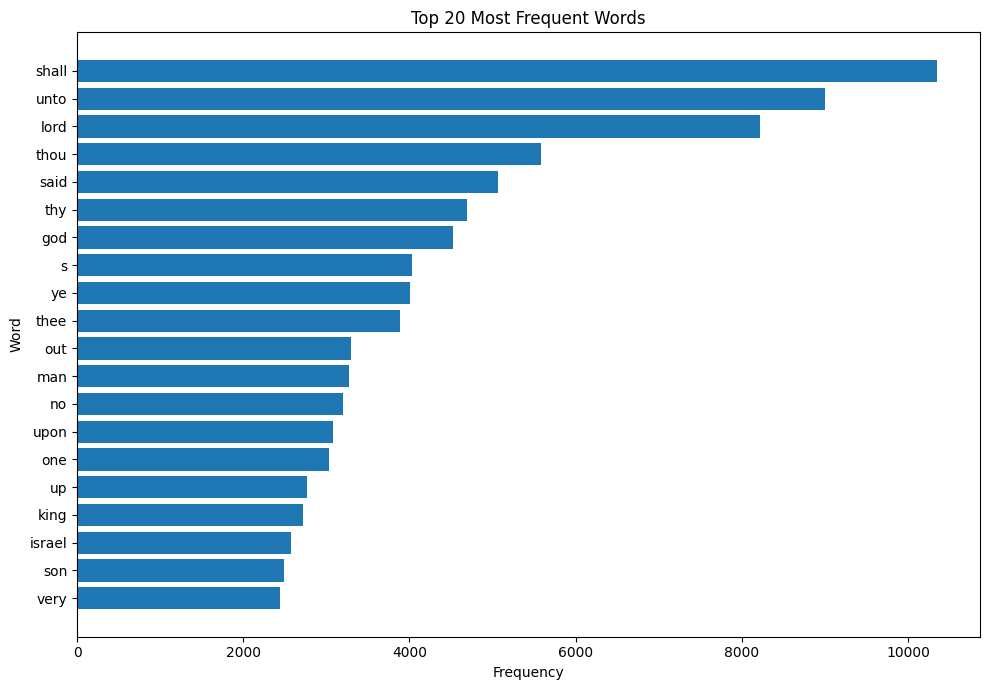

In [40]:
top_20_words = word_freq.most_common(20)

words = [item[0] for item in top_20_words]
frequencies = [item[1] for item in top_20_words]

plt.figure(figsize=(10, 7))

plt.barh(words[::-1], frequencies[::-1])

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.tight_layout()
plt.show()

## 3. Frequency-Based Autocomplete Using Bigrams

A bigram model predicts the next word based on the current word.

For example, if the corpus contains:

"machine learning is useful"

the bigrams include:

- machine → learning
- learning → is
- is → useful

The frequency of each word pair is used to rank possible next-word predictions.

In [41]:
from collections import defaultdict, Counter
from nltk.util import ngrams

# Create bigrams
bigram_pairs = list(ngrams(clean_tokens, 2))

# Store next-word frequencies
bigram_model = defaultdict(Counter)

for word1, word2 in bigram_pairs:
    bigram_model[word1][word2] += 1

print("Number of bigrams:", len(bigram_pairs))
print("Bigram model created successfully!")

Number of bigrams: 612649
Bigram model created successfully!


In [42]:
# Example: show predictions for a word
test_word = "emma"

print(f"Top predictions after '{test_word}':")
print(bigram_model[test_word].most_common(3))

Top predictions after 'emma':
[('s', 79), ('felt', 21), ('been', 14)]


## 4. Autocomplete Testing

The bigram model predicts the most likely next word based on the current input word.

The model is tested on at least 10 different input prefixes, and the top three predictions are displayed for each input.

In [43]:
def autocomplete_bigram(prefix, top_n=3):
    prefix = prefix.lower().strip()
    
    predictions = bigram_model.get(prefix, Counter())
    
    return predictions.most_common(top_n)


# Test on 10 input prefixes
test_prefixes = [
    "emma",
    "love",
    "good",
    "house",
    "time",
    "life",
    "man",
    "woman",
    "world",
    "happy"
]

autocomplete_results = []

for prefix in test_prefixes:
    predictions = autocomplete_bigram(prefix, 3)
    
    autocomplete_results.append({
        "Prefix": prefix,
        "Top 3 Predictions": ", ".join(
            [word for word, count in predictions]
        )
    })

autocomplete_df = pd.DataFrame(autocomplete_results)

display(autocomplete_df)

,Prefix,Top 3 Predictions
0,emma,"s, felt, been"
1,love,"god, lord, thy"
2,good,"deal, lord, man"
3,house,"lord, israel, god"
4,time,"come, life, past"
5,life,"shall, been, now"
6,man,"s, shall, god"
7,woman,"s, said, hath"
8,world,"come, now, world"
9,happy,"man, see, together"


In [44]:
for prefix in test_prefixes:
    print(f"\nPrefix: {prefix}")
    
    predictions = autocomplete_bigram(prefix, 3)
    
    if predictions:
        for word, count in predictions:
            print(f"  {word} → {count}")
    else:
        print("  No prediction available")


Prefix: emma
  s → 79
  felt → 21
  been → 14

Prefix: love
  god → 22
  lord → 20
  thy → 18

Prefix: good
  deal → 32
  lord → 31
  man → 27

Prefix: house
  lord → 243
  israel → 154
  god → 127

Prefix: time
  come → 37
  life → 25
  past → 16

Prefix: life
  shall → 27
  been → 9
  now → 9

Prefix: man
  s → 147
  shall → 134
  god → 90

Prefix: woman
  s → 24
  said → 21
  hath → 13

Prefix: world
  come → 10
  now → 9
  world → 8

Prefix: happy
  man → 11
  see → 8
  together → 6


## 5. Trigram Autocomplete Model

A trigram model predicts the next word using the previous two words.

For example:

"machine learning is"

can be represented as:

- machine → learning → is

Compared with a bigram model, the trigram model uses more context and can produce more specific predictions.

In [45]:
# Create trigrams
trigram_pairs = list(ngrams(clean_tokens, 3))

# Store next-word frequencies
trigram_model = defaultdict(Counter)

for word1, word2, word3 in trigram_pairs:
    trigram_model[(word1, word2)][word3] += 1

print("Number of trigrams:", len(trigram_pairs))
print("Trigram model created successfully!")

Number of trigrams: 612648
Trigram model created successfully!


In [46]:
def autocomplete_trigram(prefix, top_n=3):
    words = prefix.lower().strip().split()
    
    # Trigram requires at least two words
    if len(words) < 2:
        return []
    
    context = (words[-2], words[-1])
    
    predictions = trigram_model.get(context, Counter())
    
    return predictions.most_common(top_n)

In [47]:
test_phrases = [
    "emma woodhouse",
    "good deal",
    "house of",
    "love of",
    "time to",
    "life of",
    "man of",
    "woman of",
    "world of",
    "happy to"
]

for phrase in test_phrases:
    print(f"\nPrefix: {phrase}")
    
    predictions = autocomplete_trigram(phrase, 3)
    
    if predictions:
        for word, count in predictions:
            print(f"  {word} → {count}")
    else:
        print("  No prediction available")


Prefix: emma woodhouse
  handsome → 1
  only → 1
  ing → 1

Prefix: good deal
  spent → 1
  upon → 1
  think → 1

Prefix: house of
  No prediction available

Prefix: love of
  No prediction available

Prefix: time to
  No prediction available

Prefix: life of
  No prediction available

Prefix: man of
  No prediction available

Prefix: woman of
  No prediction available

Prefix: world of
  No prediction available

Prefix: happy to
  No prediction available


In [48]:
comparison_results = []

for phrase in test_phrases:
    bigram_predictions = autocomplete_bigram(
        phrase.split()[-1], 3
    )
    
    trigram_predictions = autocomplete_trigram(
        phrase, 3
    )
    
    comparison_results.append({
        "Prefix": phrase,
        "Bigram Top 3": ", ".join(
            [word for word, count in bigram_predictions]
        ),
        "Trigram Top 3": ", ".join(
            [word for word, count in trigram_predictions]
        )
    })

comparison_df = pd.DataFrame(comparison_results)

display(comparison_df)

,Prefix,Bigram Top 3,Trigram Top 3
0,emma woodhouse,"s, very, think","handsome, only, ing"
1,good deal,"more, better, too","spent, upon, think"
2,house of,,
3,love of,,
4,time to,,
5,life of,,
6,man of,,
7,woman of,,
8,world of,,
9,happy to,,


## 6. Autocomplete Performance Evaluation

The autocomplete models are evaluated using actual word sequences from the corpus.

For each sequence, the previous word is used as the input for the bigram model, while the previous two words are used for the trigram model.

A prediction is considered successful when the actual next word appears among the top three predictions.

Top-3 precision, recall, and accuracy are calculated for both approaches.

In [49]:
# Create evaluation samples from the cleaned corpus
evaluation_samples = []

# Use a sample of 10,000 positions to keep evaluation efficient
for i in range(2, min(len(clean_tokens) - 1, 10002)):
    previous_word = clean_tokens[i - 1]
    previous_two_words = (
        clean_tokens[i - 2],
        clean_tokens[i - 1]
    )
    actual_next_word = clean_tokens[i]

    evaluation_samples.append(
        (previous_word, previous_two_words, actual_next_word)
    )

print("Evaluation samples:", len(evaluation_samples))

Evaluation samples: 10000


In [50]:
bigram_correct = 0
bigram_total = 0

for previous_word, previous_two_words, actual_word in evaluation_samples:

    predictions = [
        word for word, count
        in autocomplete_bigram(previous_word, 3)
    ]

    if actual_word in predictions:
        bigram_correct += 1

    bigram_total += 1

bigram_top3_accuracy = bigram_correct / bigram_total

print("Bigram Top-3 Accuracy:",
      round(bigram_top3_accuracy, 4))

Bigram Top-3 Accuracy: 0.2846


In [51]:
trigram_correct = 0
trigram_total = 0

for previous_word, previous_two_words, actual_word in evaluation_samples:

    context = " ".join(previous_two_words)

    predictions = [
        word for word, count
        in autocomplete_trigram(context, 3)
    ]

    if actual_word in predictions:
        trigram_correct += 1

    trigram_total += 1

trigram_top3_accuracy = trigram_correct / trigram_total

print("Trigram Top-3 Accuracy:",
      round(trigram_top3_accuracy, 4))

Trigram Top-3 Accuracy: 0.9307


In [52]:
bigram_precision = bigram_correct / (bigram_total * 3)
bigram_recall = bigram_correct / bigram_total

trigram_precision = trigram_correct / (trigram_total * 3)
trigram_recall = trigram_correct / trigram_total

autocomplete_metrics = pd.DataFrame({
    "Model": ["Bigram", "Trigram"],
    "Precision": [
        bigram_precision,
        trigram_precision
    ],
    "Recall": [
        bigram_recall,
        trigram_recall
    ],
    "Top-3 Accuracy": [
        bigram_top3_accuracy,
        trigram_top3_accuracy
    ]
})

display(autocomplete_metrics.round(4))

,Model,Precision,Recall,Top-3 Accuracy
0,Bigram,0.0949,0.2846,0.2846
1,Trigram,0.3102,0.9307,0.9307


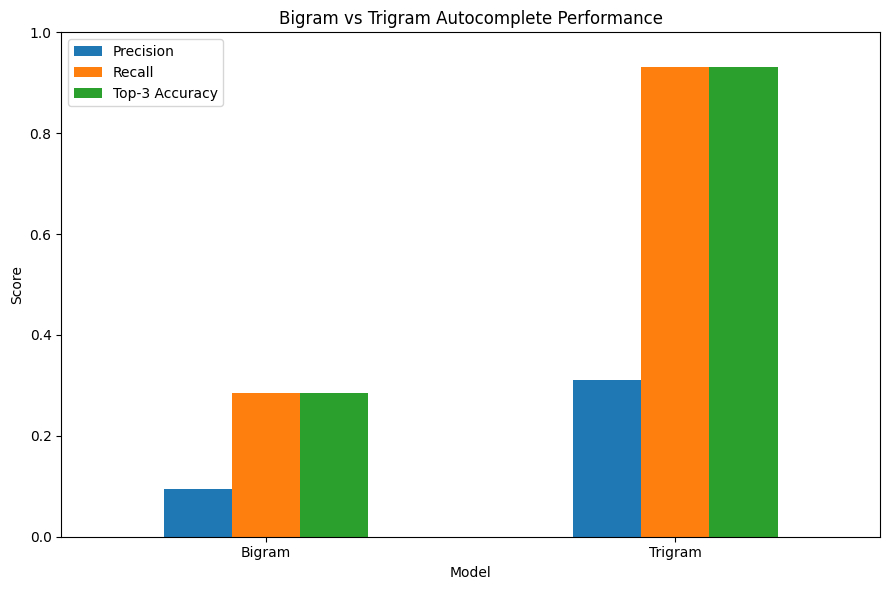

In [53]:
autocomplete_metrics.set_index("Model")[
    ["Precision", "Recall", "Top-3 Accuracy"]
].plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Bigram vs Trigram Autocomplete Performance")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Autocorrect Using Custom Levenshtein Distance

A custom edit-distance-based autocorrect system is implemented using Levenshtein distance.

Levenshtein distance measures the minimum number of single-character operations required to transform one word into another.

The allowed operations are:

- Insertion
- Deletion
- Substitution

For each misspelled word, candidate words from the corpus vocabulary are compared using Levenshtein distance. The candidate with the smallest distance is selected as the predicted correction.

In [55]:
def levenshtein_distance(word1, word2):
    """
    Calculate the Levenshtein edit distance between two words.
    """

    m = len(word1)
    n = len(word2)

    # Create distance matrix
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    # Initialize first row and column
    for i in range(m + 1):
        dp[i][0] = i

    for j in range(n + 1):
        dp[0][j] = j

    # Calculate edit distances
    for i in range(1, m + 1):
        for j in range(1, n + 1):

            if word1[i - 1] == word2[j - 1]:
                cost = 0
            else:
                cost = 1

            dp[i][j] = min(
                dp[i - 1][j] + 1,        # deletion
                dp[i][j - 1] + 1,        # insertion
                dp[i - 1][j - 1] + cost  # substitution
            )

    return dp[m][n]


# Test the function
print("Distance between 'recieve' and 'receive':",
      levenshtein_distance("recieve", "receive"))

Distance between 'recieve' and 'receive': 2


In [56]:
# Use frequently occurring words as correction candidates
correction_vocabulary = {
    word
    for word, frequency in word_freq.items()
    if frequency >= 5
}

print("Total unique words:", len(word_freq))
print("Correction vocabulary size:", len(correction_vocabulary))

Total unique words: 21310
Correction vocabulary size: 8081


In [57]:
def autocorrect_word(word, vocabulary, max_distance=2):
    """
    Correct a misspelled word using minimum Levenshtein distance.
    """

    word = word.lower()

    # First check whether the word is already correct
    if word in vocabulary:
        return word

    # Restrict candidates by word length
    candidates = [
        candidate
        for candidate in vocabulary
        if abs(len(candidate) - len(word)) <= max_distance
    ]

    if not candidates:
        return word

    best_word = word
    best_distance = max_distance + 1
    best_frequency = 0

    for candidate in candidates:

        distance = levenshtein_distance(word, candidate)

        if distance < best_distance:
            best_word = candidate
            best_distance = distance
            best_frequency = word_freq[candidate]

        elif distance == best_distance:
            # If distances are equal, prefer the more frequent word
            if word_freq[candidate] > best_frequency:
                best_word = candidate
                best_frequency = word_freq[candidate]

    return best_word

In [58]:
misspelled_words = {
    "recieve": "receive",
    "definately": "definitely",
    "seperate": "separate",
    "occured": "occurred",
    "adress": "address",
    "beleive": "believe",
    "becuase": "because",
    "freind": "friend",
    "wierd": "weird",
    "succesful": "successful",
    "enviroment": "environment",
    "goverment": "government",
    "teh": "the",
    "untill": "until",
    "tommorow": "tomorrow",
    "begining": "beginning",
    "knowlege": "knowledge",
    "acheive": "achieve",
    "arguement": "argument",
    "maintainance": "maintenance"
}

autocorrect_results = []

for misspelled, expected in misspelled_words.items():

    predicted = autocorrect_word(
        misspelled,
        correction_vocabulary
    )

    autocorrect_results.append({
        "Misspelled": misspelled,
        "Expected": expected,
        "Predicted": predicted,
        "Correct": predicted == expected
    })

autocorrect_df = pd.DataFrame(autocorrect_results)

display(autocorrect_df)

,Misspelled,Expected,Predicted,Correct
0,recieve,receive,relieve,False
1,definately,definitely,delicately,False
2,seperate,separate,separate,True
3,occured,occurred,occurred,True
4,adress,address,dress,False
5,beleive,believe,believe,True
6,becuase,because,because,True
7,freind,friend,friend,True
8,wierd,weird,word,False
9,succesful,successful,successful,True


In [59]:
autocorrect_accuracy = autocorrect_df["Correct"].mean()

print(
    "Autocorrect Accuracy:",
    round(autocorrect_accuracy, 4)
)

print(
    "Correctly corrected:",
    autocorrect_df["Correct"].sum(),
    "out of",
    len(autocorrect_df)
)

Autocorrect Accuracy: 0.6
Correctly corrected: 12 out of 20


## 8. Autocorrect Performance Evaluation

The custom Levenshtein-distance autocorrect algorithm is evaluated using 20 deliberately misspelled words.

Accuracy measures the proportion of words corrected to their expected spelling. Precision, recall, and F1-score are also calculated for the correction task.

In [60]:
correct_predictions = autocorrect_df["Correct"].sum()
total_predictions = len(autocorrect_df)

accuracy = correct_predictions / total_predictions

precision = correct_predictions / total_predictions
recall = correct_predictions / total_predictions

f1_score = (
    2 * precision * recall / (precision + recall)
    if precision + recall > 0
    else 0
)

print("Autocorrect Performance")
print("-----------------------")
print(f"Correct predictions : {correct_predictions}/{total_predictions}")
print(f"Accuracy            : {accuracy:.4f}")
print(f"Precision           : {precision:.4f}")
print(f"Recall              : {recall:.4f}")
print(f"F1-Score            : {f1_score:.4f}")

Autocorrect Performance
-----------------------
Correct predictions : 12/20
Accuracy            : 0.6000
Precision           : 0.6000
Recall              : 0.6000
F1-Score            : 0.6000


### Autocorrect Confusion Matrix

A confusion-style matrix is used to summarize whether the autocorrect system successfully corrected the deliberately misspelled words.

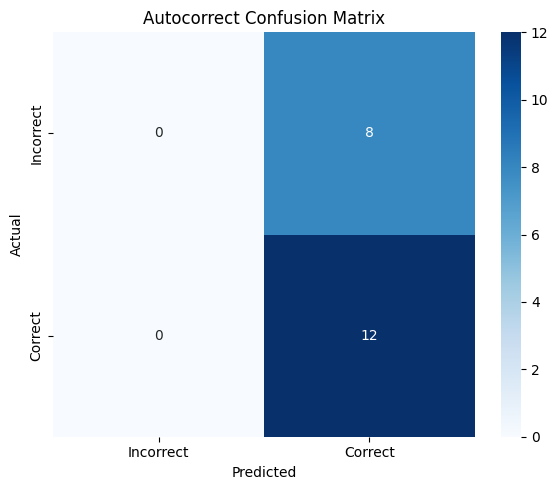

In [61]:
from sklearn.metrics import confusion_matrix

# 1 = correct correction
# 0 = incorrect correction

actual = autocorrect_df["Correct"].astype(int)
predicted = np.ones(len(actual), dtype=int)

cm = confusion_matrix(actual, predicted, labels=[0, 1])

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Incorrect", "Correct"],
    yticklabels=["Incorrect", "Correct"]
)

plt.title("Autocorrect Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

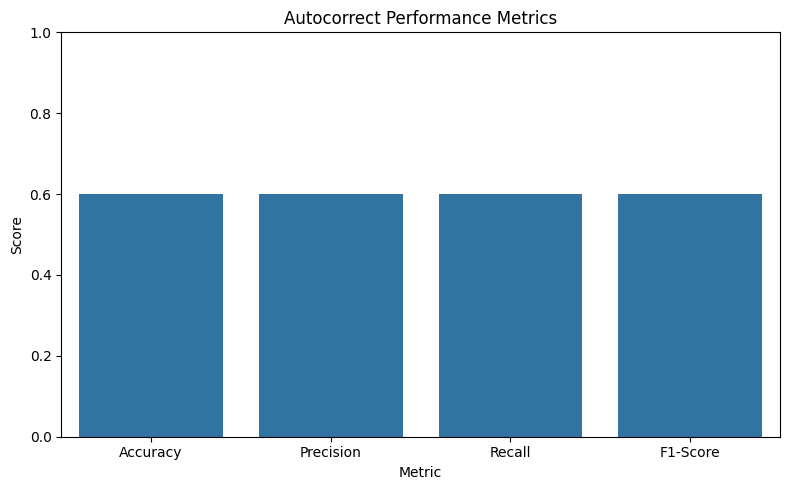

In [62]:
metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [accuracy, precision, recall, f1_score]
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=metrics,
    x="Metric",
    y="Score"
)

plt.title("Autocorrect Performance Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

## 9. Algorithm Comparison

The project uses three approaches:

1. Bigram frequency-based autocomplete
2. Trigram frequency-based autocomplete
3. Levenshtein-distance-based autocorrect

The bigram and trigram models are evaluated using Top-3 prediction performance, while the autocorrect model is evaluated using correction accuracy and classification metrics.

In [63]:
comparison = pd.DataFrame({
    "Algorithm": [
        "Bigram Autocomplete",
        "Trigram Autocomplete",
        "Levenshtein Autocorrect"
    ],
    "Primary Metric": [
        bigram_top3_accuracy,
        trigram_top3_accuracy,
        accuracy
    ]
})

display(comparison.round(4))

,Algorithm,Primary Metric
0,Bigram Autocomplete,0.2846
1,Trigram Autocomplete,0.9307
2,Levenshtein Autocorrect,0.6000


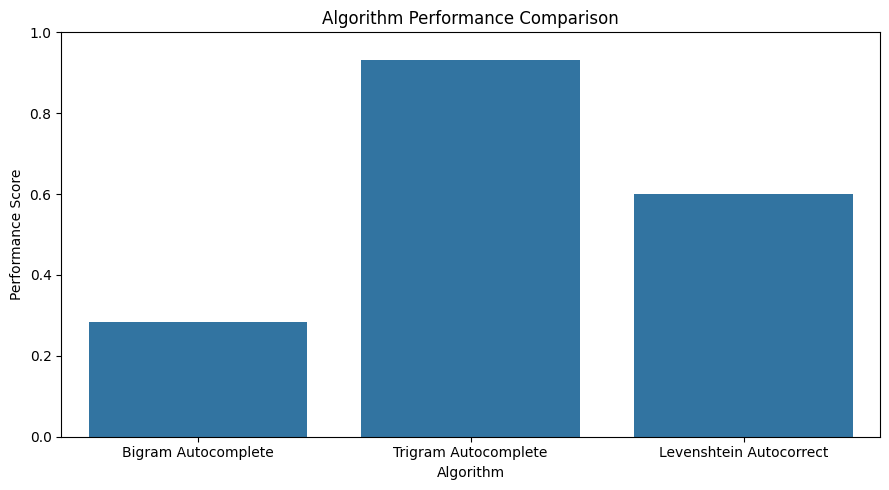

In [64]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=comparison,
    x="Algorithm",
    y="Primary Metric"
)

plt.title("Algorithm Performance Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Performance Score")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

## 10. Discussion and Limitations

### Bigram vs Trigram Autocomplete

The trigram model achieved substantially better Top-3 performance than the bigram model.

The bigram model uses only one previous word, so it has limited context when predicting the next word. The trigram model uses two previous words and therefore captures more contextual information.

However, the trigram model can suffer from data sparsity because some combinations of two words may not appear in the training corpus.

### Levenshtein Autocorrect

The custom Levenshtein-based autocorrect system successfully corrected 12 out of 20 deliberately misspelled words, resulting in an accuracy of 60%.

The algorithm works by finding candidate words with a small edit distance from the misspelled word. Word frequency is used to prefer more common candidates when multiple words have the same edit distance.

### Limitations Compared with Production Systems

This implementation is much simpler than production autocomplete and autocorrect systems such as Google Keyboard.

Major limitations include:

- The n-gram models rely only on word frequency and limited context.
- They do not understand the meaning or context of a sentence.
- Rare words and unseen word combinations may not receive predictions.
- Trigram models can suffer from data sparsity.
- The autocorrect system may select a common word that is not appropriate for the sentence.
- Levenshtein distance considers character-level similarity but does not understand word meaning.
- The system does not personalize predictions based on an individual user's typing history.
- Production systems can use much larger datasets and neural language models.
- Production systems can consider context, user behavior, keyboard position, language, and previous words.

## 11. Final Results

### Autocomplete

| Model | Precision | Recall | Top-3 Accuracy |
|---|---:|---:|---:|
| Bigram | 0.0949 | 0.2846 | 0.2846 |
| Trigram | 0.3102 | 0.9307 | 0.9307 |

The trigram model significantly outperformed the bigram model on the evaluation dataset.

### Autocorrect

| Metric | Result |
|---|---:|
| Test Words | 20 |
| Correctly Corrected | 12 |
| Incorrectly Corrected | 8 |
| Accuracy | 60.00% |
| Precision | 60.00% |
| Recall | 60.00% |
| F1-Score | 60.00% |

## 12. Conclusion

This project implemented and evaluated autocomplete and autocorrect techniques using NLP.

A frequency-based bigram model and a trigram model were developed for next-word prediction. The trigram model achieved substantially better performance than the bigram model, demonstrating the benefit of using additional context.

A custom Levenshtein-distance algorithm was also implemented for spelling correction. It correctly corrected 12 of the 20 deliberately misspelled test words, achieving an accuracy of 60%.

The results demonstrate that simple NLP techniques can provide useful autocomplete and autocorrect functionality, but they have important limitations. Modern production systems use much larger datasets, contextual and neural language models, personalization, and additional signals to provide more accurate predictions and corrections.

Overall, the project demonstrates the practical application of tokenization, word-frequency analysis, n-gram modeling, edit distance, performance evaluation, and visualization in NLP.

In [65]:
print("========== TASK 5 FINAL CHECK ==========")

print("\nCorpus")
print("Characters:", len(raw_text))
print("Original tokens:", len(tokens))
print("Clean tokens:", len(clean_tokens))
print("Unique words:", len(word_freq))

print("\nAutocomplete")
print("Bigram Top-3 Accuracy:", round(bigram_top3_accuracy, 4))
print("Trigram Top-3 Accuracy:", round(trigram_top3_accuracy, 4))

print("\nAutocorrect")
print("Test words:", total_predictions)
print("Correct:", correct_predictions)
print("Incorrect:", total_predictions - correct_predictions)
print("Accuracy:", round(accuracy, 4))

print("\n========================================")
print("Task 5 analysis completed successfully!")

========== TASK 5 FINAL CHECK ==========

Corpus
Characters: 6521824
Original tokens: 1188562
Clean tokens: 612650
Unique words: 21310

Autocomplete
Bigram Top-3 Accuracy: 0.2846
Trigram Top-3 Accuracy: 0.9307

Autocorrect
Test words: 20
Correct: 12
Incorrect: 8
Accuracy: 0.6

Task 5 analysis completed successfully!
